In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment is working")

Environment is working


In [2]:
!pip install pyreadr

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 1.5 MB/s eta 0:00:02
   ----------------- ---------------------- 1.0/2.4 MB 1.7 MB/s eta 0:00:01
   ------------------------------ --------- 1.8/2.4 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 2.3 MB/s  0:00:01



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import requests

url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)
with open("../raw_data/dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

print("Download complete")

Download complete


In [5]:
import pyreadr

result = pyreadr.read_r("../raw_data/dt_simulated_weekly.RData")

print(result.keys())

odict_keys(['dt_simulated_weekly'])


In [6]:
df = result["dt_simulated_weekly"]

df.head()

,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DATE                208 non-null    object 
 1   revenue             208 non-null    float64
 2   tv_S                208 non-null    float64
 3   ooh_S               208 non-null    float64
 4   print_S             208 non-null    float64
 5   facebook_I          208 non-null    float64
 6   search_clicks_P     208 non-null    float64
 7   search_S            208 non-null    float64
 8   competitor_sales_B  208 non-null    int32  
 9   facebook_S          208 non-null    float64
 10  events              208 non-null    str    
 11  newsletter          208 non-null    float64
dtypes: float64(9), int32(1), object(1), str(1)
memory usage: 18.8+ KB


In [8]:
df.describe()

,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,newsletter
count,2.080000e+02,208.000000,208.000000,208.000000,2.080000e+02,208.000000,208.000000,2.080000e+02,208.000000,208.000000
mean,1.822143e+06,14843.691218,43217.941026,3728.632265,8.153415e+06,16945.206847,5915.512821,5.538025e+06,2145.657826,22386.523669
std,7.162286e+05,28558.366546,83991.426655,6483.070232,1.169913e+07,13614.093674,4702.502612,2.077192e+06,3160.363803,19104.164424
min,6.722500e+05,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,2.240235e+06,0.000000,301.000000
25%,1.165211e+06,0.000000,0.000000,0.000000,0.000000e+00,6280.684504,2353.333333,3.589581e+06,0.000000,9010.500000
50%,1.874514e+06,0.000000,0.000000,0.000000,0.000000e+00,14265.252495,4806.666667,5.538524e+06,0.000000,19401.653846
75%,2.378407e+06,18406.706667,50858.133333,4767.833333,1.373742e+07,25236.843560,8536.666667,7.311814e+06,3623.012233,27546.500000
max,3.827520e+06,158046.573333,500361.600000,31922.311111,5.943276e+07,52188.128214,17880.000000,9.984742e+06,15400.391408,96236.000000


In [9]:
df["DATE"] = pd.to_datetime(df["DATE"])

df.dtypes

DATE                  datetime64[s]
revenue                     float64
tv_S                        float64
ooh_S                       float64
print_S                     float64
facebook_I                  float64
search_clicks_P             float64
search_S                    float64
competitor_sales_B            int32
facebook_S                  float64
events                          str
newsletter                  float64
dtype: object

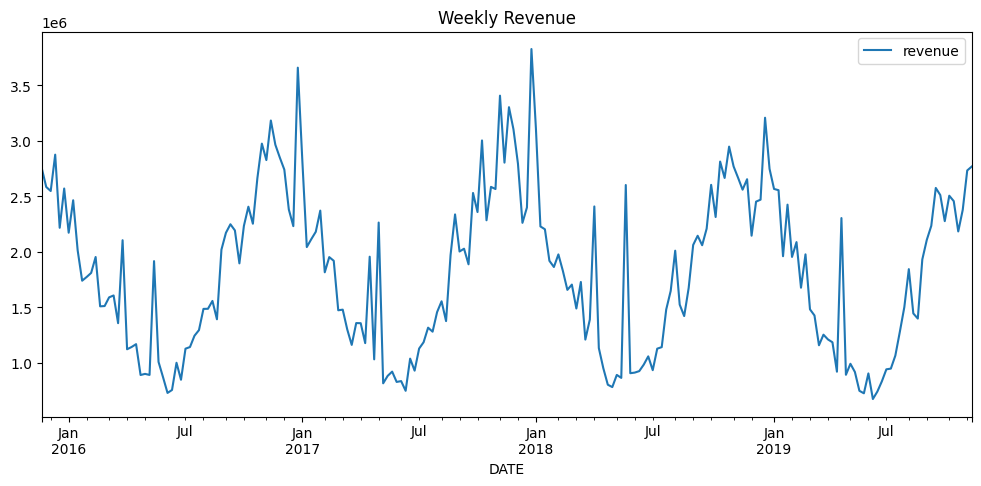

In [12]:
import matplotlib.pyplot as plt
df.plot(x="DATE", y="revenue", figsize=(12,5), title="Weekly Revenue")
plt.show()

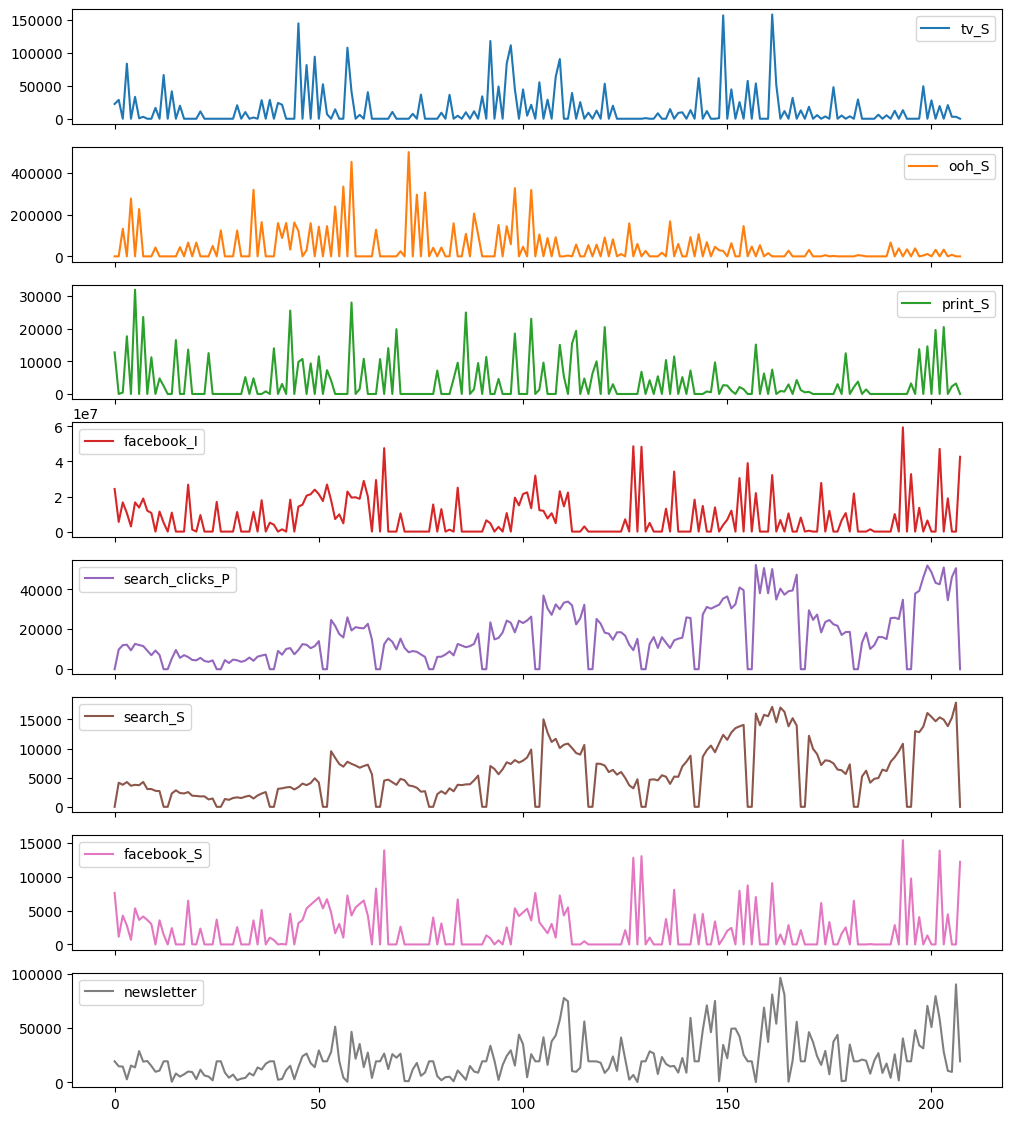

In [13]:
media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_I",
    "search_clicks_P",
    "search_S",
    "facebook_S",
    "newsletter"
]

df[media_cols].plot(subplots=True, figsize=(12,14))
plt.show()

In [14]:
corr = df[["revenue"] + media_cols].corr()

corr["revenue"].sort_values(ascending=False)

revenue            1.000000
search_S           0.442774
search_clicks_P    0.427513
tv_S               0.419869
newsletter         0.406099
facebook_S         0.317594
facebook_I         0.315126
print_S            0.230415
ooh_S              0.095279
Name: revenue, dtype: float64